<a href="https://colab.research.google.com/github/ajitesh68/machine-learning-practice-/blob/main/TF002_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INRODUCTION TO REGRESSION WITH NEURAL NETWORKS


there are many definition for a regression prblm but in our case we are going other combination of variables , even shorter .... predicting a number

In [40]:
#IMPORT tensorflow
import tensorflow as tf
print(tf.__version__)

2.18.0


Creating data to view and fit

In [41]:
import numpy as np
import matplotlib.pyplot as plt

#crate features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0], dtype=float)

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0], dtype=float)

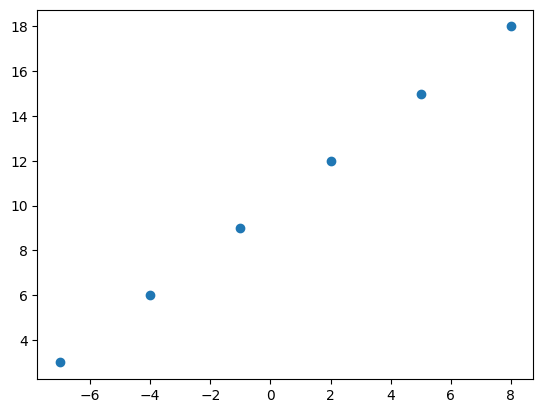

In [42]:
plt.scatter(x,y)

In [43]:
y == x+10

array([ True,  True,  True,  True,  True,  True])

Input and Output shapes

In [44]:
#create a demo tensor for our houseing prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])

In [45]:
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [46]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [47]:
x[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [48]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [49]:
x[0].ndim

0

In [50]:
x[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [51]:
#convert numpy arrays into tensors with dtype float 32
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)

In [52]:
x , y


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [53]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape
#there is no shape as there is single value or scalar value

(TensorShape([]), TensorShape([]))

Steps in creating a model with TensorFlow

1. Creating a model - define the i/p and o/p layers , as well as the hidden layers of a deep learning model

2. Comppiling a model - define a loss fnc (in other words, the fnc which tells our model how wrong our model how wrong it is ) and optimizer (tells our model how to improve the patterns its learning ) and evaluation metrics (what we can use to interpret the performance of our model).

3. Fitting a model- letting the model try to find patterns between x & y (features and labels)

In [54]:
#Set random seed
tf.random.set_seed

#1. create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])# mae are short for mean absolute error
              #sgd is short for stochastic gradient descent

#3. Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 865ms/step - loss: 10.2316 - mae: 10.2316
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - loss: 10.2191 - mae: 10.2191
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 10.2066 - mae: 10.2066
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 10.1941 - mae: 10.1941
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 10.1816 - mae: 10.1816


In [55]:
#check out x and y
x , y

(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [56]:
#Try add make prediction using our model
import numpy as np

y_pred = model.predict(np.array([[17.0]]))  # double brackets to make it 2D
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[9.602084]]


In [57]:
y_pred + 10   # mae: 9.8731 hence we our adding 10 to y predicted

array([[19.602085]], dtype=float32)

Improving our model

Steps we can improve our model, by altering the steps we took to create a model

1. Create a model -- here we might add more layersm increase the number of hidden units (all called neurons) within each of the hidden layers , change the activation fnc of each layer

2. "Compiling a model" -- here we might change the optimization fnc or perhaps the "learning rate" of the optimization fnc

3. "Fitting a model" -- here we might fit a model for more ""epochs"" (leave it training for longer) or on more data (give the model more example to learn from).

In [58]:
#higher the learning rate the more model pushes to improve at every step and lower the learning rate
# the model take lower steps to improve the model

In [59]:
import numpy as np

# If x was like this:
# x = [1.0, 2.0, 3.0, 4.0]

# Do this instead:
x = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([2.0, 4.0, 6.0, 8.0])  # keep y as 1D


In [60]:
#Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#3. Fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step - loss: 1.6110 - mae: 1.6110
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 1.5385 - mae: 1.5385
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.4660 - mae: 1.4660
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 1.3935 - mae: 1.3935
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.3210 - mae: 1.3210
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 1.2485 - mae: 1.2485
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 1.1760 - mae: 1.1760
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 1.1035 - mae: 1.1035
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 1.0310 - mae: 1.0310
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 0.9585 - mae: 0.9585
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.8860 - mae: 0.8860
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.8135 - mae: 0.8135
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71m

In [61]:
#Remind ourselves of the data
x,y


(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [62]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[33.44508]], dtype=float32)

In [63]:
#Let's see if we can make another to improve our model

#create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation= None),
    tf.keras.layers.Dense(1)
])

#2 . Compile the model
model.compile(loss ="mae",
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])


#fit the model
model.fit(x,y,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 5.2858 - mae: 5.2858
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 5.2345 - mae: 5.2345
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 5.1832 - mae: 5.1832
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 5.1320 - mae: 5.1320
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 5.0808 - mae: 5.0808
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 5.0297 - mae: 5.0297
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 4.9786 - mae: 4.9786
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 4.9275 - mae: 4.9275
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 4.8765 - mae: 4.8765
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 4.8255 - mae: 4.8255
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 4.7745 - mae: 4.7745
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 4.7235 - mae: 4.7235
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms

In [64]:
#Remind ourselves of the data
x,y

(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [65]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[28.755278]], dtype=float32)

Common Ways To Improve the Deep Model

1. Adding The Layers
2. Increase the number of hidden units
3. Change the activation fnc
4. Change the optimization fnc
5. Change the learning rate(potentially the most imp hyperparameter of many diff neural networks)
6. Fitting more data
7. Fitting for longer



Evaluating a Model

In practice, a typical workflow you will go through while building a neural networks is:

Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it....

When it comes to evaluation.... there are 3 words you should memorize:

"Visualize, Visualize , Visualize"

It's good idea to visualize:

* the data we are working with? What does it look like ?
* The model itself - What does our model look like?
* The training of a model how does a model perform while learn
* The prediction of a model how does a prediction of a model line up against the ground truth ( the original labels)?

In [66]:
#Make a bigger dataset  most probably for a good prediction or training

x  = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [67]:
#we want our model to learn this formula
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

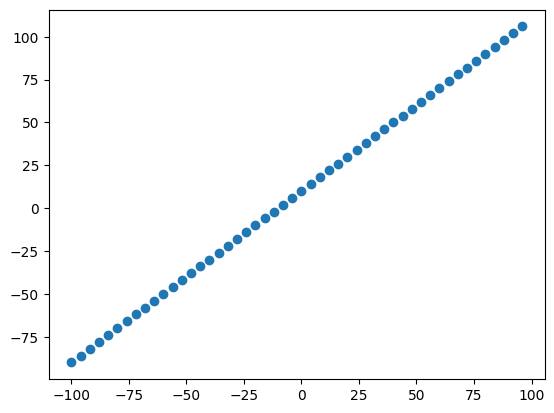

In [68]:
#visulaize our data
import matplotlib.pyplot as plt
plt.scatter(x,y)


# There are 3 sets ..........

**Training set** :- The model learn from this data , typically contains 80% of the the total dataset available

**Validation dataset** :- The model gets tuned on this data , typically contains 10%-15% of the the total dataset available

**Testing dataset** :- The model gets test on this data , typically contains 10%-15% of the the total dataset available

In [69]:
len(x)

50

In [70]:
#Split the data into training and testing dataset

x_train = x[:40]#80% of the data is been given for training from 1-40     #first 40 are training samples
x_test = x[40:]#20% of the data is been given for testing from 41-50

y_train = x[:40]
y_test = x[40:]

In [71]:
len(x_test), len(x_train), len(y_test), len(y_train)

(10, 40, 10, 40)

visualize the data the test and train split

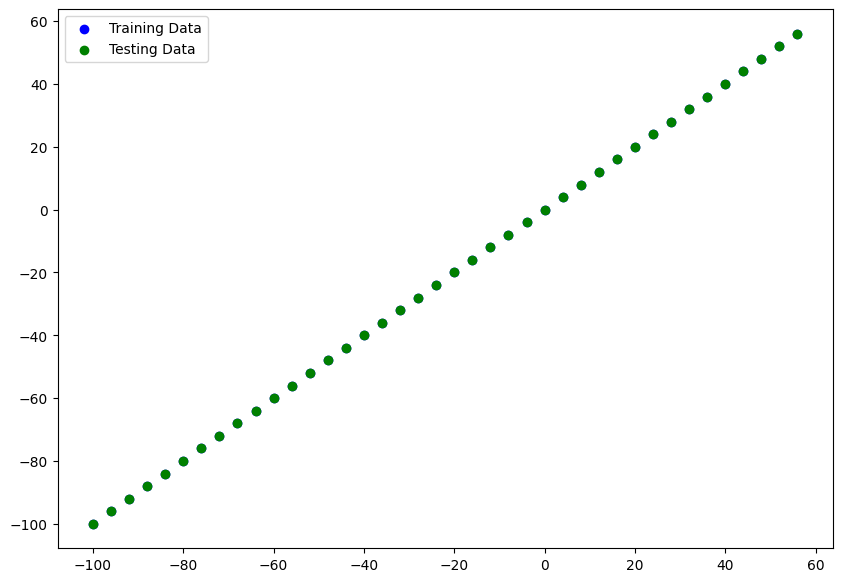

In [72]:
plt.figure(figsize=(10,7))
#now plot training data with blue
plt.scatter(x_train,y_train, c='b', label='Training Data')
#now plot testing data with green
plt.scatter(x_train,y_train, c='g', label='Testing Data')

plt.legend()

In [73]:
#lets have a look how to build a neural network

#1.create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2.Compile the model

model.compile(optimizer=tf.keras.optimizers.SGD(), loss=tf.keras.losses.mae, metrics=["mae"])

#3. fit the model


In [74]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [85]:
#Lets create a model which build automatically after defining the input_shape
tf.random.set_seed(42)


#1.create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10 , input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1 , name="output_layer")
],name="model_1")
                                                            #a fully connected layer is same as Dense layer
#2.Compile the model (same as above)

model.compile(optimizer=tf.keras.optimizers.SGD(), loss=tf.keras.losses.mae, metrics=["mae"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Total params : total number of parameters in the model

Trainable params : these are the parameters(patterns) the model can update as it trains

Non Trainable params : These are not updated during training (this is typical when you bring in an already learn patterns or parameters from the other models from the transfer learning)

In [87]:
#lets fit our model to training data
model.fit(x_train,y_train,epochs=100)


#verbose=0 we are not getting any output


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 40.0643 - mae: 40.0643 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 33.2939 - mae: 33.2939 
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 31.6641 - mae: 31.6641 
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 30.4321 - mae: 30.4321
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4.2579 - mae: 4.2579
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 16.8839 - mae: 16.8839
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 20.0212 - mae: 20.0212
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 24.4499 - mae: 24.4499
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 24.0167 - mae: 24.0167 
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.6520 - mae: 7.6520
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 12.7769 - mae: 12.7769
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 16.8781 - mae: 16.8781
Epoch 13/100
2/2 ━━━━━━━━

In [88]:
#you can go through MIT's introduction to DL

model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

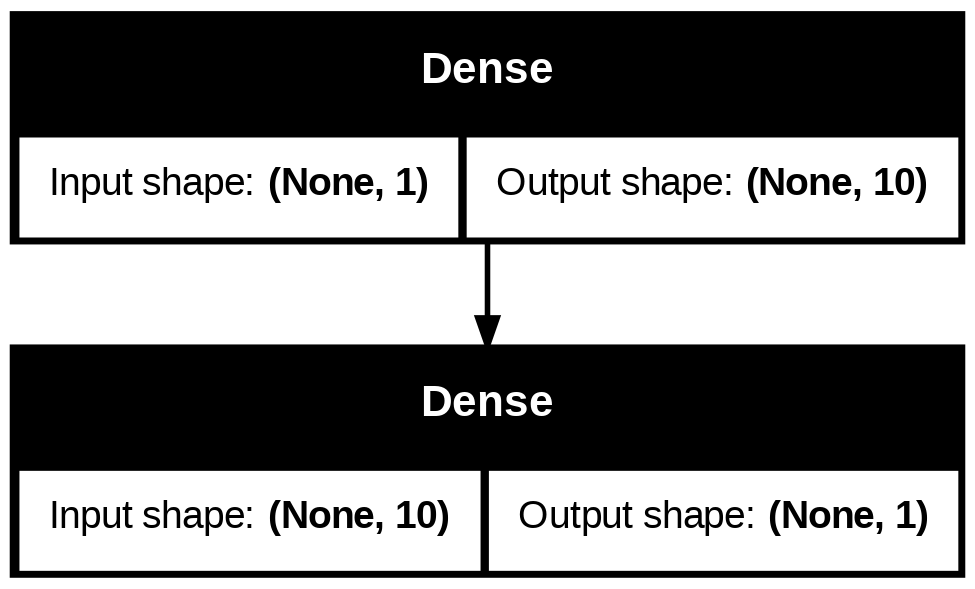

In [89]:
from tensorflow.keras.utils import plot_model

plot_model(model=model , show_shapes=True)

**Visualizing our model Prediction**

the best way to visualize the model prediction is to plot them around the ground truth labels

often you will see this in the form of y_test or y_true and y_pred (ground truth versus your model )




In [90]:
y_pred = model.predict(x_test)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


array([[ 95.36024 ],
       [101.720276],
       [108.08032 ],
       [114.44038 ],
       [120.800415],
       [127.16047 ],
       [133.52051 ],
       [139.88055 ],
       [146.2406  ],
       [152.60063 ]], dtype=float32)

In [93]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([60, 64, 68, 72, 76, 80, 84, 88, 92, 96], dtype=int32)>

now we have to align them in order to predict model performance

if our model predict data 100% the above y_pred will line up like y_tes

**note** : If you feel like you will use any functionality in future it is better to convert into a function  

In [100]:
import matplotlib.pyplot as plt

def plot_prediction(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=y_pred):
    """Plot training data, test data, and compare predictions to ground truth labels."""

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', label='Training Data')

    # Plot testing data in green
    plt.scatter(test_data, test_labels, c='g', label='Testing Data')

    # Plot predictions in red
    plt.scatter(test_data, predictions, c='r', label='Predictions')

    plt.legend();



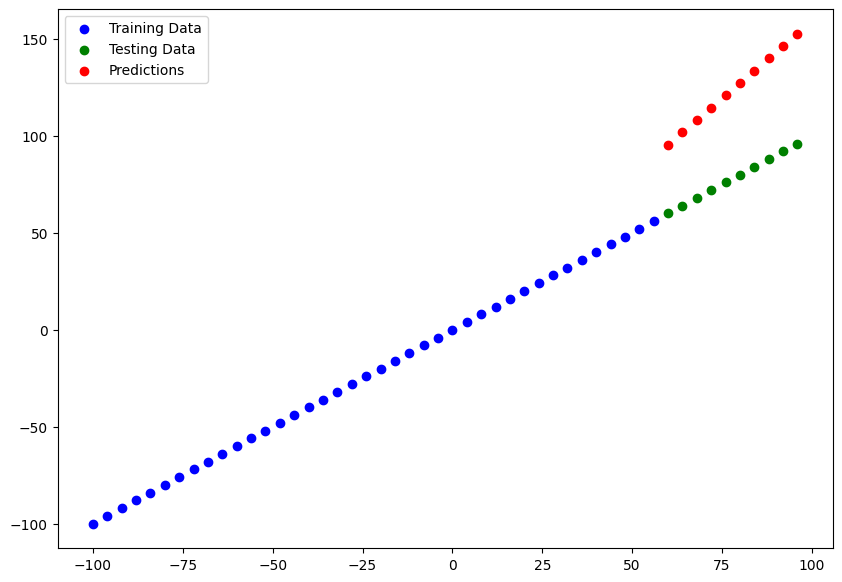

In [105]:
plot_prediction()